# Day 2 — Linear Regression from Scratch (NumPy)
**Date:** 2026-06-24 · **Phase:** 1 — ML Foundations · **Tracker reference:** Day 2

**Objective for today:** understand linear & logistic regression math + gradient descent, implement linear regression from scratch (normal equation *and* batch gradient descent), and connect regularization + evaluation metrics back to the Iris baseline from Day 1.

This notebook lives in `01-ml-foundations-iris/notebooks/` as a second, standalone notebook — no need for a new repo for this one, it's a foundational exercise that builds toward the NumPy MLP later in the week.

## 1. Linear regression — the math

**Hypothesis (model):**
$$\hat{y} = X\theta = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_n x_n$$

where $X$ is the feature matrix with a leading column of 1s (for the intercept $\theta_0$), and $\theta$ is the weight vector we're solving for.

**Cost function (Mean Squared Error):**
$$J(\theta) = \frac{1}{2m}\sum_{i=1}^{m}(\hat{y}^{(i)} - y^{(i)})^2 = \frac{1}{2m}\|X\theta - y\|^2$$

The $\frac{1}{2}$ is just a convenience — it cancels neatly when we differentiate.

There are **two ways** to find the $\theta$ that minimizes $J(\theta)$:

1. **Normal equation** (closed-form, solve directly):
$$\theta = (X^TX)^{-1}X^Ty$$
   No iteration needed — but it requires inverting an $(n+1)\times(n+1)$ matrix, which is $O(n^3)$. Fine for small $n$, painful for thousands of features.

2. **Gradient descent** (iterative): start with some $\theta$, repeatedly step in the direction that reduces $J(\theta)$ the fastest:
$$\theta := \theta - \alpha \cdot \nabla_\theta J(\theta), \qquad \nabla_\theta J(\theta) = \frac{1}{m}X^T(X\theta - y)$$
   $\alpha$ is the **learning rate**. Scales to huge feature counts and datasets that don't fit in memory — the workhorse for everything from logistic regression to deep nets.

We'll implement **both** below and confirm they agree.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

np.random.seed(42)
plt.rcParams["figure.figsize"] = (6, 4)

## 2. A synthetic dataset

A clean, single-feature dataset (true relationship $y = 4 + 3x + \text{noise}$) makes it easy to *see* the line gradient descent converges to, and to sanity-check both implementations against a known ground truth.

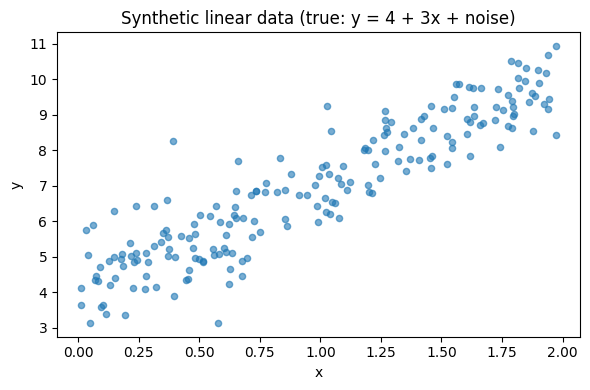

In [2]:
m = 200
X_raw = 2 * np.random.rand(m, 1)               # one feature, values in [0, 2)
true_theta0, true_theta1 = 4.0, 3.0
y = true_theta0 + true_theta1 * X_raw + np.random.randn(m, 1) * 0.8   # add noise

plt.scatter(X_raw, y, alpha=0.6, s=20)
plt.xlabel("x"); plt.ylabel("y")
plt.title("Synthetic linear data (true: y = 4 + 3x + noise)")
plt.tight_layout()
plt.savefig("images/linear_data.png", dpi=120)
plt.show()

## 3. Normal equation (closed form)

Add a column of 1s to $X$ for the intercept, then solve $\theta = (X^TX)^{-1}X^Ty$ directly. `np.linalg.pinv` is used instead of a literal inverse — it's numerically safer (works even if $X^TX$ is singular or near-singular).

In [3]:
X_b = np.c_[np.ones((m, 1)), X_raw]   # add bias column -> shape (m, 2)

theta_normal_eq = np.linalg.pinv(X_b.T @ X_b) @ X_b.T @ y
print("Normal equation solution  [theta0, theta1] =", theta_normal_eq.ravel())

Normal equation solution  [theta0, theta1] = [4.08416092 2.96877157]


## 4. Batch gradient descent — implementation

Each step uses **the entire training set** to compute the gradient (hence "batch"). We track the cost at every iteration so we can plot convergence.

In [4]:
class LinearRegressionScratch:
    def __init__(self, learning_rate=0.1, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.theta = None
        self.cost_history = []

    def fit(self, X, y):
        m, n = X.shape
        X_b = np.c_[np.ones((m, 1)), X]          # add bias column
        self.theta = np.zeros((n + 1, 1))

        for _ in range(self.n_iterations):
            y_pred = X_b @ self.theta
            error = y_pred - y
            cost = (1 / (2 * m)) * np.sum(error ** 2)
            self.cost_history.append(cost)

            gradient = (1 / m) * X_b.T @ error
            self.theta -= self.lr * gradient
        return self

    def predict(self, X):
        m = X.shape[0]
        X_b = np.c_[np.ones((m, 1)), X]
        return X_b @ self.theta


gd_model = LinearRegressionScratch(learning_rate=0.5, n_iterations=200)
gd_model.fit(X_raw, y)
print("Batch GD solution          [theta0, theta1] =", gd_model.theta.ravel())

Batch GD solution          [theta0, theta1] = [4.08416089 2.9687716 ]


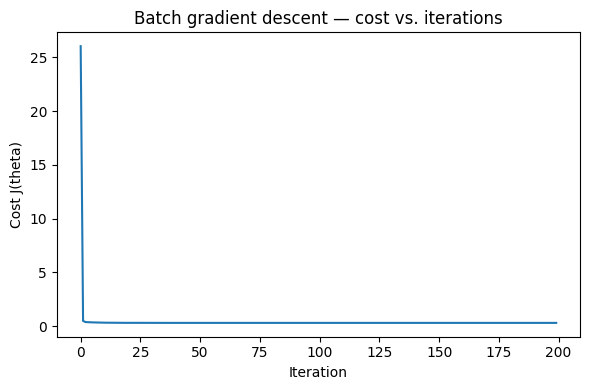

Final cost: 0.2988  |  Cost after iter 1: 26.0307


In [5]:
plt.plot(gd_model.cost_history)
plt.xlabel("Iteration"); plt.ylabel("Cost J(theta)")
plt.title("Batch gradient descent — cost vs. iterations")
plt.tight_layout()
plt.savefig("images/gd_cost_curve.png", dpi=120)
plt.show()
print(f"Final cost: {gd_model.cost_history[-1]:.4f}  |  Cost after iter 1: {gd_model.cost_history[0]:.4f}")

## 5. Sanity check — compare against `sklearn.LinearRegression`

If the math is right, the normal equation, our gradient descent, and scikit-learn's (also closed-form, via SVD) solution should all land on essentially the same $\theta$.

In [6]:
sk_model = LinearRegression()
sk_model.fit(X_raw, y)
sk_theta = np.array([sk_model.intercept_[0], sk_model.coef_[0][0]])

print(f"{'Method':<22}{'theta0':>10}{'theta1':>10}")
print(f"{'Normal equation':<22}{theta_normal_eq[0][0]:>10.4f}{theta_normal_eq[1][0]:>10.4f}")
print(f"{'Batch GD (scratch)':<22}{gd_model.theta[0][0]:>10.4f}{gd_model.theta[1][0]:>10.4f}")
print(f"{'sklearn':<22}{sk_theta[0]:>10.4f}{sk_theta[1]:>10.4f}")
print(f"\n(True generating values were theta0={true_theta0}, theta1={true_theta1} — "
      f"differences from that are just noise in the synthetic data, not implementation error.)")

Method                    theta0    theta1
Normal equation           4.0842    2.9688
Batch GD (scratch)        4.0842    2.9688
sklearn                   4.0842    2.9688

(True generating values were theta0=4.0, theta1=3.0 — differences from that are just noise in the synthetic data, not implementation error.)


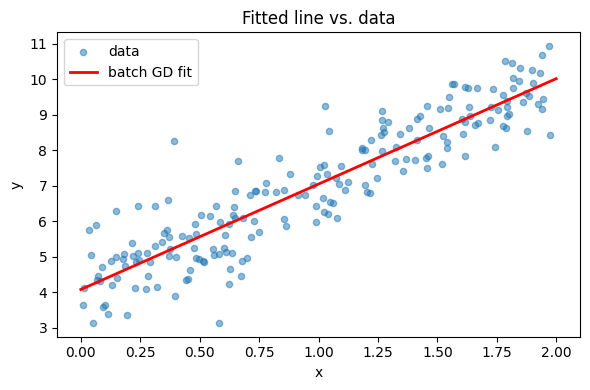

In [7]:
plt.scatter(X_raw, y, alpha=0.5, s=20, label="data")
x_line = np.array([[0], [2]])
plt.plot(x_line, gd_model.predict(x_line), "r-", linewidth=2, label="batch GD fit")
plt.xlabel("x"); plt.ylabel("y")
plt.title("Fitted line vs. data")
plt.legend()
plt.tight_layout()
plt.savefig("images/linear_fit.png", dpi=120)
plt.show()

## 6. Gradient descent: batch vs. SGD vs. mini-batch *(interview Q)*

| Variant | Gradient computed from | Behavior |
|---|---|---|
| **Batch GD** | the *entire* training set, every step | Smooth, stable convergence; one step per full pass over the data → slow on large datasets, guaranteed to step "downhill" each time. |
| **Stochastic GD (SGD)** | a *single* random sample, every step | Very noisy path (bounces around the minimum) but each step is cheap, and the noise can help it escape shallow local minima / saddle points. |
| **Mini-batch GD** | a small random *batch* (e.g. 32–256 samples) | The practical default — far less noisy than SGD, far cheaper per step than full batch, and it's what makes GPU-vectorized training efficient. This is what virtually every deep learning training loop uses. |

A quick way to see the noise difference: shrink the "batch" used for each gradient step and watch the cost curve get jumpier.

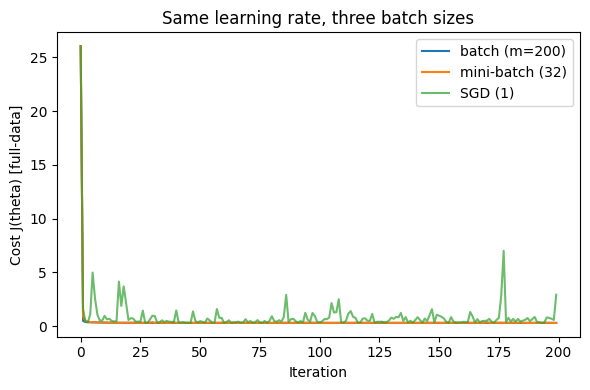

In [8]:
def gradient_descent_variant(X, y, lr=0.5, n_iterations=200, batch_size=None, seed=0):
    # batch_size=None -> full-batch GD. batch_size=1 -> SGD. else -> mini-batch.
    rng = np.random.RandomState(seed)
    m, n = X.shape
    X_b = np.c_[np.ones((m, 1)), X]
    theta = np.zeros((n + 1, 1))
    history = []
    bs = m if batch_size is None else batch_size

    for _ in range(n_iterations):
        idx = rng.choice(m, size=bs, replace=False)
        Xb_sample, y_sample = X_b[idx], y[idx]
        error = Xb_sample @ theta - y_sample
        cost = (1 / (2 * m)) * np.sum((X_b @ theta - y) ** 2)   # full-data cost, for a fair comparison
        history.append(cost)
        gradient = (1 / bs) * Xb_sample.T @ error
        theta -= lr * gradient
    return theta, history

_, hist_batch = gradient_descent_variant(X_raw, y, batch_size=None)
_, hist_mini  = gradient_descent_variant(X_raw, y, batch_size=32)
_, hist_sgd   = gradient_descent_variant(X_raw, y, batch_size=1)

plt.plot(hist_batch, label="batch (m=200)")
plt.plot(hist_mini, label="mini-batch (32)")
plt.plot(hist_sgd, label="SGD (1)", alpha=0.7)
plt.xlabel("Iteration"); plt.ylabel("Cost J(theta) [full-data]")
plt.title("Same learning rate, three batch sizes")
plt.legend()
plt.tight_layout()
plt.savefig("images/gd_variants.png", dpi=120)
plt.show()

Notice batch GD is the smoothest line, SGD is visibly noisier step to step, and mini-batch sits in between — exactly what the table above predicts. (All three use the *same* learning rate here purely to make the noise visible; in practice SGD/mini-batch are usually run with smaller learning rates and many more, cheaper steps.)

## 7. Logistic regression — how it relates *(theory only today — no scratch build required)*

Linear regression predicts a continuous number. Logistic regression reuses the **same linear core** ($z = X\theta$) but squashes it through the **sigmoid** function to get a probability:

$$\sigma(z) = \frac{1}{1 + e^{-z}}, \qquad \hat{p} = \sigma(X\theta) \in (0, 1)$$

Instead of MSE, it's trained with **log-loss / binary cross-entropy**, which penalizes confident-and-wrong predictions far more harshly than MSE would:

$$J(\theta) = -\frac{1}{m}\sum_{i=1}^{m}\Big[y^{(i)}\log(\hat{p}^{(i)}) + (1-y^{(i)})\log(1-\hat{p}^{(i)})\Big]$$

The elegant part: the **gradient has the exact same form** as linear regression's —

$$\nabla_\theta J(\theta) = \frac{1}{m}X^T(\hat{p} - y)$$

— just with $\hat{p} = \sigma(X\theta)$ instead of $\hat{y} = X\theta$. This is *why* the `LinearRegressionScratch` class above is most of the way to a logistic regression class: swap the cost function, run predictions through `sigmoid()`, and the gradient-descent loop barely changes. That's a clean target for a future "from scratch" exercise once trees/ensembles (Day 3) are out of the way.

This is also exactly what Day 1's `LogisticRegression` on Iris was doing under the hood — just generalized to 3 classes via one-vs-rest / multinomial softmax instead of a single sigmoid.

## 8. Regularization: L1 vs. L2 *(interview Q)*

Both add a penalty on the size of the weights to the cost function, to discourage the model from fitting noise:

$$J_{\text{ridge}}(\theta) = J(\theta) + \lambda\sum_{j=1}^{n}\theta_j^2 \qquad\qquad J_{\text{lasso}}(\theta) = J(\theta) + \lambda\sum_{j=1}^{n}|\theta_j|$$

| | L2 (Ridge) | L1 (Lasso) |
|---|---|---|
| Penalty | sum of *squared* weights | sum of *absolute* weights |
| Effect on weights | shrinks them smoothly toward zero | can push weights **exactly** to zero |
| Use it when | you believe most features matter a little | you want automatic feature selection / sparsity |
| Combine both | **ElasticNet** — a weighted mix of both penalties | |

A quick visual of the "exactly zero" claim, on a dataset with some genuinely useless features mixed in: 

In [9]:
from sklearn.linear_model import Ridge, Lasso

rng = np.random.RandomState(0)
m2, n_features = 60, 10
X_demo = rng.randn(m2, n_features)
true_w = np.array([5, -3, 0, 0, 2, 0, 0, 0, 1.5, 0])   # only 4 of 10 features actually matter
y_demo = X_demo @ true_w + rng.randn(m2) * 0.5

ridge = Ridge(alpha=2.0).fit(X_demo, y_demo)
lasso = Lasso(alpha=0.5).fit(X_demo, y_demo)

print(f"{'feature':<10}{'true_w':>8}{'ridge':>10}{'lasso':>10}")
for i in range(n_features):
    print(f"x{i:<9}{true_w[i]:>8.1f}{ridge.coef_[i]:>10.3f}{lasso.coef_[i]:>10.3f}")
print(f"\nLasso zeroed out {(np.abs(lasso.coef_) < 1e-8).sum()} of {n_features} weights — "
      f"and they're (mostly) the ones that were actually 0 in true_w.")

feature     true_w     ridge     lasso
x0             5.0     4.679     4.270
x1            -3.0    -2.810    -2.099
x2             0.0     0.075     0.000
x3             0.0     0.040     0.000
x4             2.0     1.786     1.170
x5             0.0    -0.086    -0.000
x6             0.0     0.064     0.000
x7             0.0    -0.054    -0.000
x8             1.5     1.297     0.727
x9             0.0     0.164     0.000

Lasso zeroed out 6 of 10 weights — and they're (mostly) the ones that were actually 0 in true_w.


## 9. Evaluation metrics: accuracy, precision, recall, F1, ROC-AUC *(theory recall)*

All but ROC-AUC come from the **confusion matrix** (for binary classification, generalizes class-by-class for multiclass):

| | Predicted positive | Predicted negative |
|---|---|---|
| **Actual positive** | TP | FN |
| **Actual negative** | FP | TN |

$$\text{Accuracy} = \frac{TP+TN}{TP+TN+FP+FN} \qquad \text{Precision} = \frac{TP}{TP+FP} \qquad \text{Recall} = \frac{TP}{TP+FN}$$

$$F1 = 2 \cdot \frac{\text{Precision}\cdot\text{Recall}}{\text{Precision}+\text{Recall}} \quad\text{(harmonic mean — punishes a big gap between the two)}$$

**When each one matters:**
- **Precision** matters most when false positives are expensive (e.g. flagging a legitimate transaction as fraud).
- **Recall** matters most when false negatives are expensive (e.g. missing an actual cancer case).
- **F1** is the go-to single number when you need a precision/recall balance and classes are imbalanced — plain accuracy would be misleading there.
- **ROC-AUC** measures ranking quality across *all* classification thresholds at once (probability the model ranks a random positive above a random negative) — useful when you care about the model's discrimination ability independent of where you set the decision threshold.

Let's apply all of these to Day 1's exact Iris setup (same split, same model) instead of just accuracy + a confusion matrix:

In [10]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize

iris = load_iris()
X_iris, y_iris = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

clf = LogisticRegression(max_iter=200).fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)

print(classification_report(y_test, y_pred, target_names=iris.target_names))

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
auc = roc_auc_score(y_test_bin, y_proba, multi_class="ovr")
print(f"Macro-average ROC-AUC (one-vs-rest): {auc:.4f}")

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

Macro-average ROC-AUC (one-vs-rest): 1.0000


On this dataset, precision/recall/F1 stay close to the 0.9667 accuracy from Day 1 — expected, since Iris is perfectly balanced with no asymmetric cost between classes. The gap between accuracy and these finer metrics shows up much more clearly on imbalanced data, which is exactly why Day 3's "how do you handle imbalanced datasets?" question pairs naturally with this.

## 10. Summary — Day 2

**Built:**
- `LinearRegressionScratch`: batch gradient descent linear regression, from scratch in NumPy, verified against both the closed-form normal equation and `sklearn.LinearRegression` — all three agree.
- A small batch-size comparison (full-batch / mini-batch / SGD) showing the noise-vs-speed tradeoff directly.

**Learned:**
- Linear regression: normal equation vs. gradient descent, and why GD scales better.
- Gradient descent variants and when each is used in practice.
- Logistic regression as linear regression's sigmoid + log-loss sibling — same gradient form.
- L1 vs. L2 regularization, and the "Lasso zeroes weights, Ridge shrinks them" distinction, seen directly in code.
- Precision/recall/F1/ROC-AUC, applied to the Day 1 Iris model instead of just defined abstractly.

**Next step (Day 3):** decision trees, random forests, gradient boosting — Project 2 (tabular ML + XGBoost), bagging vs. boosting, handling imbalanced data, and k-fold/stratified/time-series cross-validation.

**Save into the repo as:** `01-ml-foundations-iris/notebooks/02_linear_regression_scratch.ipynb`, with the three new PNGs going into that repo's `images/` folder (`linear_data.png`, `gd_cost_curve.png`, `linear_fit.png`, `gd_variants.png`).